In [1]:
# Importing Important Libaries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [3]:
# Import the Dataset
df = pd.read_csv('/content/processes2.csv')

In [4]:
df.shape

(2095, 14)

In [5]:
df.sample(10)

,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
344,1062,Maruti,2014,509999,100000,Diesel,Individual,Manual,Second Owner,5,74.00,kmpl,22.90,1248
529,1599,Maruti,2012,225000,40000,Petrol,Individual,Manual,First Owner,5,46.30,kmpl,19.70,796
1709,5077,Maruti,2012,220000,70000,Diesel,Individual,Manual,Second Owner,5,73.94,kmpl,23.20,1248
801,2481,Hyundai,2016,875000,40000,Diesel,Individual,Manual,First Owner,5,88.73,kmpl,22.54,1396
295,932,Mahindra,2012,254999,70000,Diesel,Individual,Manual,Second Owner,5,65.00,kmpl,20.80,1461
1595,4785,Maruti,2015,400000,49907,Petrol,Dealer,Manual,First Owner,5,67.04,kmpl,21.63,998
1476,4435,Toyota,2017,650000,120000,Diesel,Individual,Manual,Second Owner,5,67.04,kmpl,23.59,1364
1392,4200,Volkswagen,2011,370000,100000,Diesel,Individual,Manual,Second Owner,5,103.60,kmpl,20.54,1598
815,2526,Hyundai,2019,1200000,40000,Diesel,Individual,Manual,First Owner,5,126.20,kmpl,22.00,1582
436,1345,Ford,2011,200000,80000,Diesel,Individual,Manual,Second Owner,5,68.00,kmpl,20.00,1399


In [6]:
df['Power'] = df['max_power (in bph)']

In [7]:
df.drop('max_power (in bph)',axis=1,inplace=True)

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2095 non-null   int64  
 1   name           2095 non-null   object 
 2   year           2095 non-null   int64  
 3   selling_price  2095 non-null   int64  
 4   km_driven      2095 non-null   int64  
 5   fuel           2095 non-null   object 
 6   seller_type    2095 non-null   object 
 7   transmission   2095 non-null   object 
 8   owner          2095 non-null   object 
 9   seats          2095 non-null   int64  
 10  Mileage Unit   2095 non-null   object 
 11  Mileage        2095 non-null   float64
 12  Engine (CC)    2095 non-null   int64  
 13  Power          2095 non-null   float64
dtypes: float64(2), int64(6), object(6)
memory usage: 229.3+ KB


In [9]:
df.describe()

,Unnamed: 0,year,selling_price,km_driven,seats,Mileage,Engine (CC),Power
count,2095.000000,2095.000000,2.095000e+03,2095.000000,2095.000000,2095.000000,2095.000000,2095.000000
mean,3155.537947,2014.052506,4.272799e+05,67413.593795,5.096897,21.397928,1205.078282,77.410427
std,1791.039215,3.273451,2.326698e+05,41580.846333,0.457000,1.209234,245.058696,19.884938
min,0.000000,2000.000000,4.595700e+04,1000.000000,4.000000,19.600000,624.000000,35.000000
25%,1589.500000,2012.000000,2.500000e+05,35000.000000,5.000000,20.360000,998.000000,67.040000
50%,3185.000000,2014.000000,3.900000e+05,60000.000000,5.000000,21.100000,1248.000000,74.000000
75%,4709.500000,2017.000000,5.555000e+05,90000.000000,5.000000,22.540000,1396.000000,88.730000
max,6256.000000,2020.000000,1.594000e+06,270000.000000,8.000000,23.590000,1598.000000,126.320000


In [10]:
print(df['selling_price'].describe())

count    2.095000e+03
mean     4.272799e+05
std      2.326698e+05
min      4.595700e+04
25%      2.500000e+05
50%      3.900000e+05
75%      5.555000e+05
max      1.594000e+06
Name: selling_price, dtype: float64


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
seats,0


## EDA

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
cate_col = df.select_dtypes(exclude=np.number).columns

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cate_col = df.select_dtypes(exclude=np.number).columns

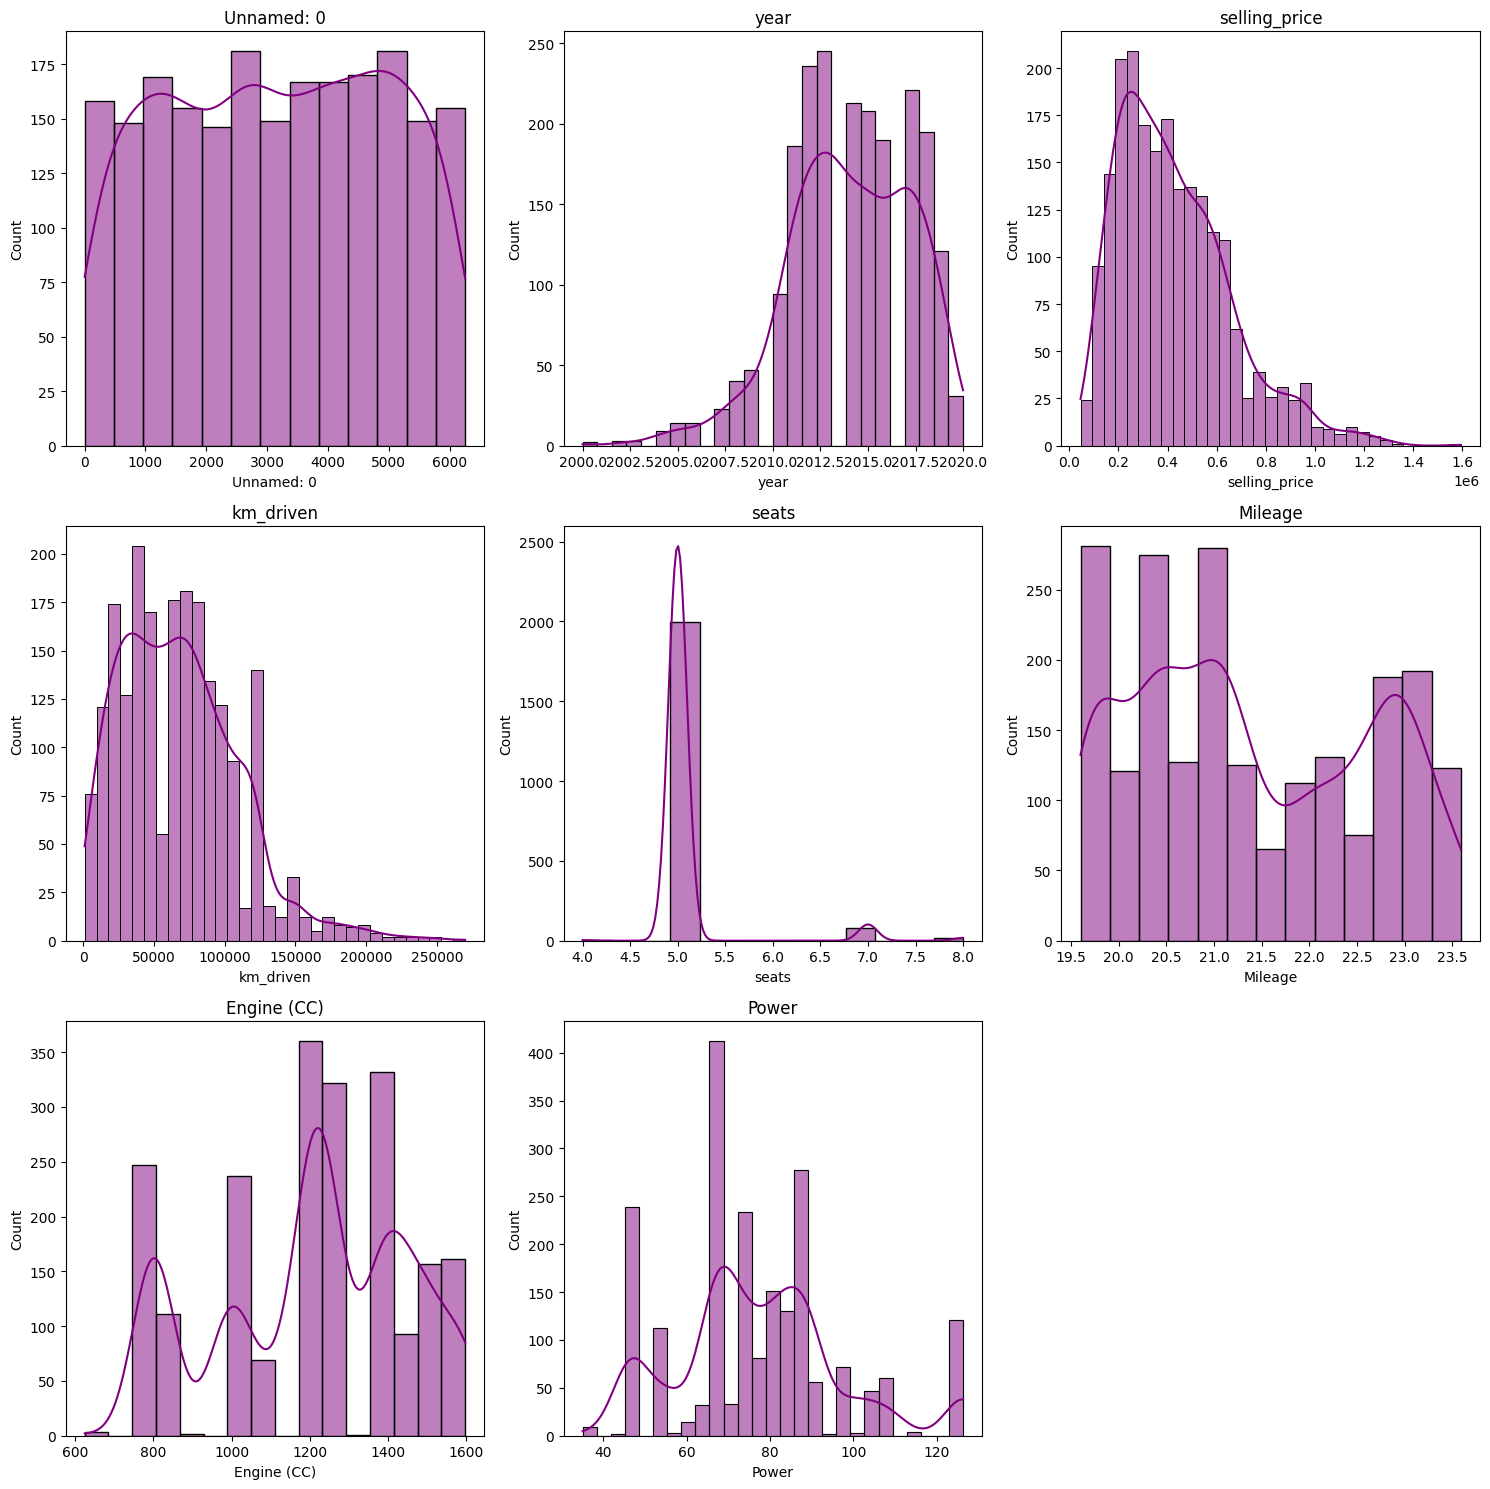

In [14]:
n = len(num_cols)

# Define subplot layout
cols = 3
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i],color ='purple')
    axes[i].set_title(col)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

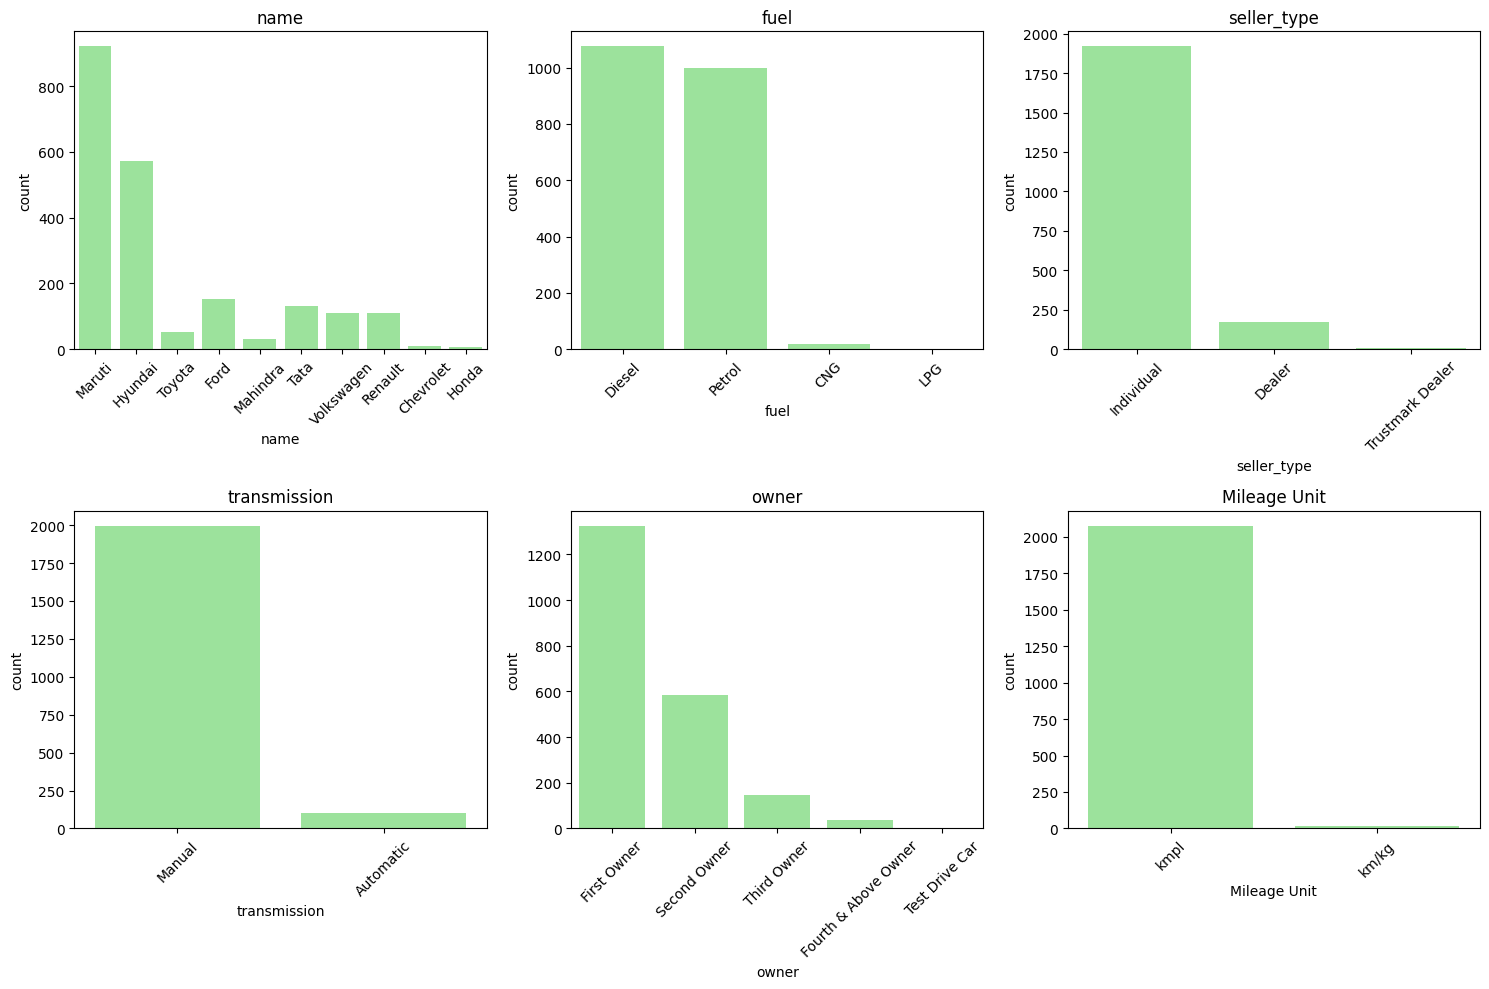

In [15]:
n = len(cate_col)

# Define subplot layout
cols = 3
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each countplot
for i, col in enumerate(cate_col):
    sns.countplot(x=df[col], ax=axes[i] , color = 'lightgreen')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

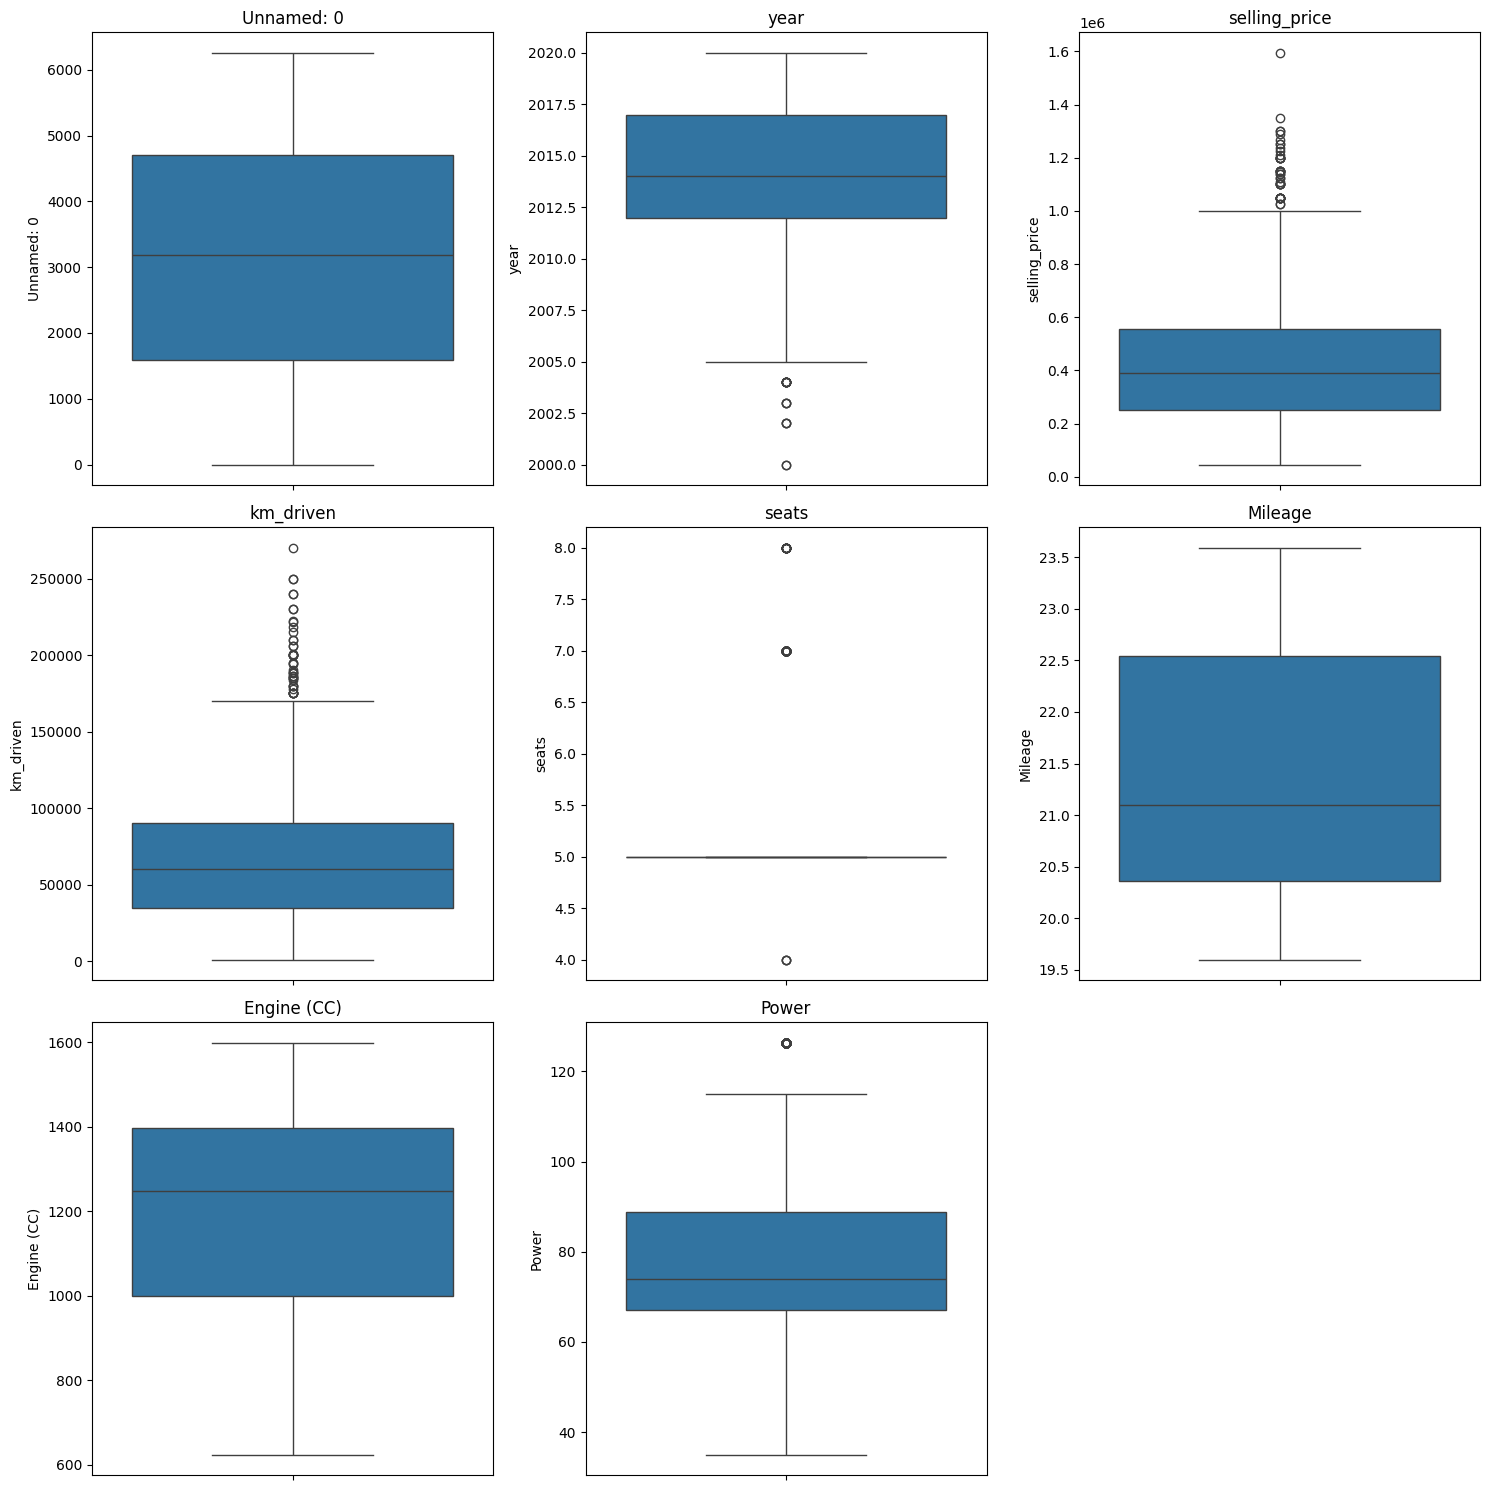

In [16]:
n = len(num_cols)

# Define subplot layout
cols = 3
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(num_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Feature Engineering

In [17]:
# Car age
current_year = 2026

df['car_age'] = current_year - df['year']

In [18]:
# KM Driven Per Year

df['km_per_year'] = df['km_driven'] / (df['car_age'] + 1)

In [19]:
premium = ['BMW','Audi','Mercedes','Jaguar','Volvo']

df['premium_brand'] = df['name'].apply(
    lambda x: 1 if any(b in x for b in premium) else 0
)

In [20]:
df['brand'] = df['name'].str.split().str[0]

In [21]:
df['old_car'] = (df['car_age'] > 10).astype(int)

In [22]:
df['is_first_owner'] = (
    df['owner'] == 'First Owner'
).astype(int)

In [23]:
df['is_automatic'] = (
    df['transmission'] == 'Automatic'
).astype(int)

In [24]:
df['dealer_sale'] = (
    df['seller_type'] == 'Dealer'
).astype(int)

In [25]:
df['selling_price'] = np.log1p(df['selling_price'])

In [26]:
freq = df['brand'].value_counts()

df['brand_freq'] = df['brand'].map(freq)

In [27]:
brand_mean = df.groupby('brand')['selling_price'].mean()

df['brand_price_mean'] = df['brand'].map(brand_mean)

In [28]:
df.shape

(2095, 24)

In [29]:
df


,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,...,car_age,km_per_year,premium_brand,brand,old_car,is_first_owner,is_automatic,dealer_sale,brand_freq,brand_price_mean
0,0,Maruti,2014,13.017005,145500,Diesel,Individual,Manual,First Owner,5,...,12,11192.307692,0,Maruti,1,1,0,0,921,12.695761
1,2,Hyundai,2010,12.323860,127000,Diesel,Individual,Manual,First Owner,5,...,16,7470.588235,0,Hyundai,1,1,0,0,571,12.881544
2,4,Hyundai,2017,12.994532,45000,Petrol,Individual,Manual,First Owner,5,...,9,4500.000000,0,Hyundai,0,1,0,0,571,12.881544
3,7,Toyota,2011,12.765691,90000,Diesel,Individual,Manual,First Owner,5,...,15,5625.000000,0,Toyota,1,1,0,0,51,13.089168
4,8,Ford,2013,12.206078,169000,Diesel,Individual,Manual,First Owner,5,...,13,12071.428571,0,Ford,1,1,0,0,153,12.929841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,6245,Maruti,2017,12.959847,12000,Petrol,Individual,Manual,First Owner,5,...,9,1200.000000,0,Maruti,0,1,0,0,921,12.695761
2091,6246,Toyota,2014,12.959847,50000,Diesel,Individual,Manual,First Owner,5,...,12,3846.153846,0,Toyota,1,1,0,0,51,13.089168
2092,6249,Maruti,2011,12.206078,73000,Petrol,Individual,Manual,First Owner,5,...,15,4562.500000,0,Maruti,1,1,0,0,921,12.695761
2093,6253,Maruti,2017,12.793862,80000,Petrol,Individual,Manual,First Owner,5,...,9,8000.000000,0,Maruti,0,1,0,0,921,12.695761


In [30]:
df.columns


Index(['Unnamed: 0', 'name', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'seats', 'Mileage Unit',
       'Mileage', 'Engine (CC)', 'Power', 'car_age', 'km_per_year',
       'premium_brand', 'brand', 'old_car', 'is_first_owner', 'is_automatic',
       'dealer_sale', 'brand_freq', 'brand_price_mean'],
      dtype='object')

In [31]:
df = df[['fuel','transmission','Mileage','Engine (CC)','Power','car_age','km_per_year','is_automatic','dealer_sale','brand_price_mean','selling_price']]

In [32]:
df

,fuel,transmission,Mileage,Engine (CC),Power,car_age,km_per_year,is_automatic,dealer_sale,brand_price_mean,selling_price
0,Diesel,Manual,23.40,1248,74.00,12,11192.307692,0,0,12.695761,13.017005
1,Diesel,Manual,23.00,1396,90.00,16,7470.588235,0,0,12.881544,12.323860
2,Petrol,Manual,20.14,1197,81.86,9,4500.000000,0,0,12.881544,12.994532
3,Diesel,Manual,23.59,1364,67.10,15,5625.000000,0,0,13.089168,12.765691
4,Diesel,Manual,20.00,1399,68.10,13,12071.428571,0,0,12.929841,12.206078
...,...,...,...,...,...,...,...,...,...,...,...
2090,Petrol,Manual,23.10,998,67.04,9,1200.000000,0,0,12.695761,12.959847
2091,Diesel,Manual,23.59,1364,67.06,12,3846.153846,0,0,13.089168,12.959847
2092,Petrol,Manual,19.70,796,46.30,15,4562.500000,0,0,12.695761,12.206078
2093,Petrol,Manual,20.51,998,67.04,9,8000.000000,0,0,12.695761,12.793862


## Handling Outliers

In [33]:
num_cols = df.select_dtypes(include=np.number).columns
cate_col = df.select_dtypes(exclude=np.number).columns


In [34]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Mileage
Number of Outliers: 0
----------------------------------------
Engine (CC)
Number of Outliers: 0
----------------------------------------
Power
Number of Outliers: 121
----------------------------------------
car_age
Number of Outliers: 17
----------------------------------------
km_per_year
Number of Outliers: 50
----------------------------------------
is_automatic
Number of Outliers: 99
----------------------------------------
dealer_sale
Number of Outliers: 169
----------------------------------------
brand_price_mean
Number of Outliers: 7
----------------------------------------
selling_price
Number of Outliers: 6
----------------------------------------


In [35]:
x = df.drop('selling_price',axis=1)
y = df['selling_price']

In [36]:
# Split the Train and Test data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Scaling in Data

In [37]:
num_cols = ['Mileage','Engine (CC)','Power','car_age','km_per_year','dealer_sale','brand_price_mean']

print(type(num_cols))

<class 'list'>


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
scaler = StandardScaler()
le = LabelEncoder()
ohe = OneHotEncoder()

In [39]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [40]:
df.columns

Index(['fuel', 'transmission', 'Mileage', 'Engine (CC)', 'Power', 'car_age',
       'km_per_year', 'is_automatic', 'dealer_sale', 'brand_price_mean',
       'selling_price'],
      dtype='object')

In [41]:
x_train = pd.get_dummies(x_train, columns=['fuel','transmission'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['fuel','transmission'], drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [42]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [43]:
print('R2_score :-',r2_score(y_test,y_pred))
print('mean_squared_error :-',mean_squared_error(y_test,y_pred))
print('mean_absolute_error :-',mean_absolute_error(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2_score :- 0.8445451622733416
mean_squared_error :- 0.05034641029502066
mean_absolute_error :- 0.1644679818907072
RMSE: 0.22438005770348812


In [44]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(alpha=0.1,max_iter=1000)
sgd.fit(x_train,y_train)
y_pred = sgd.predict(x_test)

In [45]:
print('R2_score :-',r2_score(y_test,y_pred))
print('mean_squared_error :-',mean_squared_error(y_test,y_pred))
print('mean_absolute_error :-',mean_absolute_error(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2_score :- 0.8234688359788599
mean_squared_error :- 0.0571722986793983
mean_absolute_error :- 0.17905549770732868
RMSE: 0.23910729532868355


In [46]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [47]:
y_pred = model.predict(x_test)

In [48]:
print('R2_score :-',r2_score(y_test,y_pred))
print('mean_squared_error :-',mean_squared_error(y_test,y_pred))
print('mean_absolute_error :-',mean_absolute_error(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2_score :- 0.8941153958591204
mean_squared_error :- 0.03429233725988052
mean_absolute_error :- 0.13443889951009055
RMSE: 0.1851819031651865


In [49]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [51]:
algortihems = {
    'Linear Regression':lr,
    'DT':DecisionTreeRegressor(),
    'RF':RandomForestRegressor(),
    'SVR':SVR(),
    'KNN':KNeighborsRegressor(),
    'Bagging':BaggingRegressor(),
    'Extra Tree':ExtraTreesRegressor(),
    'AdaBoost':AdaBoostRegressor(),
    'Gradient Boosting':GradientBoostingRegressor(),
    'XGB':XGBRegressor(),
    'LGBM':LGBMRegressor(),
    'CatBoost':CatBoostRegressor(verbose=False),
}


## prediction in test data

In [52]:
result = []

for name,model in algortihems.items():

    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    result.append([name, r2, mse, mae, rmse])

results = pd.DataFrame(result,columns=['Model Name','R2_score','MSE','MAE','RMSE'])
results.sort_values(by='R2_score',ascending=False)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 1676, number of used features: 9
[LightGBM] [Info] Start training from score 12.827394


,Model Name,R2_score,MSE,MAE,RMSE
11,CatBoost,0.905703,0.030540,0.127553,0.174756
10,LGBM,0.899401,0.032581,0.130839,0.180501
2,RF,0.894011,0.034326,0.133832,0.185273
8,Gradient Boosting,0.892230,0.034903,0.134155,0.186824
3,SVR,0.887692,0.036373,0.135164,0.190716
9,XGB,0.887464,0.036446,0.139789,0.190909
5,Bagging,0.887433,0.036457,0.138325,0.190936
6,Extra Tree,0.881613,0.038341,0.144863,0.195810
4,KNN,0.857505,0.046149,0.152111,0.214824
7,AdaBoost,0.844599,0.050329,0.175203,0.224341


## HyperParameter Tuning

In [53]:
# Select First 4 Best Model for this

from sklearn.model_selection import RandomizedSearchCV

In [54]:
cat_model = CatBoostRegressor(verbose=0, random_state=42)

param_dist = {
    "iterations": [200, 400, 600, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 7, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.6, 0.8, 1.0]
}

cat_random = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

cat_random.fit(x_train, y_train)

print("Best Parameters:")
print(cat_random.best_params_)

print("\nBest CV Score:")
print(cat_random.best_score_)

Best Parameters:
{'subsample': 0.6, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 5}

Best CV Score:
0.9111854658203804


In [55]:
best_cat = cat_random.best_estimator_

y_pred = best_cat.predict(x_test)

print("R2 :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 : 0.9058942185534802
MAE: 0.12676666500684744
RMSE: 0.17457831088032566


In [56]:
lgb_model = LGBMRegressor(random_state=42)

param_dist = {
    "n_estimators": [200,300,400,500,700,1000],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "max_depth": [-1,5,7,10,15],
    "num_leaves": [20,31,40,50,70],
    "subsample": [0.7,0.8,0.9,1.0],
    "colsample_bytree": [0.7,0.8,0.9,1.0]
}

lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(x_train, y_train)

print("Best Parameters:")
print(lgb_random.best_params_)

print("\nBest CV Score:")
print(lgb_random.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 1676, number of used features: 9
[LightGBM] [Info] Start training from score 12.827394
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [57]:
best_lgb = lgb_random.best_estimator_

y_pred = best_lgb.predict(x_test)

print("R2 :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 : 0.8990962051937768
MAE: 0.1296864846816725
RMSE: 0.1807739652348882


In [58]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('mean_squared_error',mean_squared_error(y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(y_test,y_pred))

R2 score 0.9000527226981537
mean_squared_error 0.032369443785061694
mean_absolute_error 0.13147714510979625


In [59]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV R2:", round(np.mean(cv_scores), 4))
print("Standard Deviation:", round(np.std(cv_scores), 4))

Cross Validation Scores:
[0.89276239 0.89559117 0.89279608 0.9182567  0.9115496 ]

Average CV R2: 0.9022
Standard Deviation: 0.0106


In [60]:
GBR = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

GBR.fit(x_train,y_train)
y_pred = GBR.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('mean_squared_error',mean_squared_error(y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(y_test,y_pred))

R2 score 0.9068543838537646
mean_squared_error 0.03016662251403628
mean_absolute_error 0.1279212990207801


In [61]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    GBR,
    x_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV R2:", round(np.mean(cv_scores), 4))
print("Standard Deviation:", round(np.std(cv_scores), 4))

Cross Validation Scores:
[0.89891063 0.90181778 0.90276088 0.91284296 0.91267187]

Average CV R2: 0.9058
Standard Deviation: 0.0058


In [62]:
# Voting

from sklearn.ensemble import VotingRegressor

vote = VotingRegressor(
    estimators=[
        ("gbr", GBR),
        ("cat", cat_model),
        ("rf", rf)
    ]
)

vote.fit(x_train, y_train)

y_pred = vote.predict(x_test)

print("R2 :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 : 0.9068850914738334
MAE: 0.12659171432235716


In [63]:
# Stacking

from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ("gbr", GBR),
        ("cat", cat_model),
        ("rf", rf)
    ]
)

stack.fit(x_train, y_train)

y_pred = stack.predict(x_test)

print("R2 :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 : 0.9070588320450208
MAE: 0.12621546622332272
